# cleaning

In [1]:
import pandas as pd
df = pd.read_excel(r"D:\decode lab intern\proj 1\Dataset for Data Analytics.xlsx")

In [2]:
df

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


In [3]:
df.isna().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [4]:
# fill columns with no copoun with no coupon as no coupon has been used
df['CouponCode'] = df['CouponCode'].fillna('No Coupon')

In [5]:
df['CouponCode'].value_counts()

CouponCode
FREESHIP     313
No Coupon    309
WINTER15     292
SAVE10       286
Name: count, dtype: int64

In [6]:
df.isna().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

In [7]:
df["OrderID"].duplicated().sum()

np.int64(0)

In [8]:
# there are no duplicates
df[df["OrderID"].duplicated()]

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice


In [9]:
df.dtypes

OrderID                       str
Date               datetime64[us]
CustomerID                    str
Product                       str
Quantity                    int64
UnitPrice                 float64
ShippingAddress               str
PaymentMethod                 str
OrderStatus                   str
TrackingNumber                str
ItemsInCart                 int64
CouponCode                    str
ReferralSource                str
TotalPrice                float64
dtype: object

In [10]:
df['ReferralSource'] = df['ReferralSource'].str.strip().str.lower()
df['CouponCode'] = df['CouponCode'].str.strip().str.lower()
df['OrderStatus'] = df['OrderStatus'].str.strip().str.lower()
df['PaymentMethod'] = df['PaymentMethod'].str.strip().str.lower()
df["CouponCode"]=df["CouponCode"].astype("category")
df["PaymentMethod"]=df["PaymentMethod"].astype("category")
df["OrderStatus"]=df["OrderStatus"].astype("category")
df["ReferralSource"]=df["ReferralSource"].astype("category")

In [11]:
df.dtypes

OrderID                       str
Date               datetime64[us]
CustomerID                    str
Product                       str
Quantity                    int64
UnitPrice                 float64
ShippingAddress               str
PaymentMethod            category
OrderStatus              category
TrackingNumber                str
ItemsInCart                 int64
CouponCode               category
ReferralSource           category
TotalPrice                float64
dtype: object

In [12]:
df.head(15)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,debit card,shipped,TRK37947903,7,save10,instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,online,shipped,TRK91186779,3,save10,referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,credit card,cancelled,TRK42903982,8,freeship,email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,debit card,returned,TRK62788070,5,save10,facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,online,delivered,TRK29241424,8,save10,email,2504.04
5,ORD200005,2023-10-23,C37249,Phone,2,245.86,934 Main St,credit card,shipped,TRK72976927,4,save10,instagram,491.72
6,ORD200006,2025-06-17,C83492,Laptop,1,664.42,986 Main St,gift card,returned,TRK96417362,6,save10,facebook,664.42
7,ORD200007,2023-05-12,C41460,Monitor,5,149.55,706 Main St,cash,shipped,TRK78809193,9,freeship,facebook,747.75
8,ORD200008,2025-04-02,C26817,Phone,2,134.28,904 Main St,gift card,cancelled,TRK61042692,2,no coupon,email,268.56
9,ORD200009,2023-11-21,C31946,Desk,4,509.38,102 Main St,credit card,shipped,TRK33478363,6,save10,google,2037.52


In [59]:
import seaborn as sns
import scipy
from scipy import stats

In [14]:
numeric_cols = ["Quantity","UnitPrice","ItemsInCart","TotalPrice"]
non_numeric_cols = ["Product","PaymentMethod","OrderStatus","CouponCode","ReferralSource"]

In [60]:
round(df[numeric_cols].mean(),2)

Quantity          2.95
UnitPrice       356.41
ItemsInCart       5.48
TotalPrice     1053.97
dtype: float64

In [16]:
df[numeric_cols].mode()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
0,1.0,127.18,5.0,211.14
1,NaN,133.39,NaN,367.34
2,NaN,136.84,NaN,410.52
3,NaN,183.67,NaN,635.90
4,NaN,228.91,NaN,2517.36
5,NaN,466.42,NaN,NaN
6,NaN,629.34,NaN,NaN


In [62]:
round(df[numeric_cols].median(),2)

Quantity         3.00
UnitPrice      364.21
ItemsInCart      5.00
TotalPrice     823.62
dtype: float64

In [63]:
round(df[numeric_cols].quantile([0.25,0.5,0.75]),2)

,Quantity,UnitPrice,ItemsInCart,TotalPrice
0.25,2.0,186.06,4.0,410.52
0.50,3.0,364.21,5.0,823.62
0.75,4.0,521.57,7.0,1578.48


In [64]:
round(df[numeric_cols].quantile(0.75)-df[numeric_cols].quantile(0.25),2)

Quantity          2.00
UnitPrice       335.51
ItemsInCart       3.00
TotalPrice     1167.96
dtype: float64

In [66]:
for i in numeric_cols:
    print(i ,"   ", round(stats.kurtosis(df[i]),2))

Quantity     -1.29
UnitPrice     -1.19
ItemsInCart     -0.71
TotalPrice     -0.05


In [67]:
for i in numeric_cols:
    print(i ,"   ", round(stats.skew(df[i]),2))

Quantity     0.03
UnitPrice     -0.03
ItemsInCart     0.0
TotalPrice     0.89


In [22]:
df[numeric_cols].min()

Quantity        1.00
UnitPrice      11.39
ItemsInCart     1.00
TotalPrice     11.39
dtype: float64

In [23]:
df[numeric_cols].max()

Quantity          5.00
UnitPrice       699.93
ItemsInCart      10.00
TotalPrice     3456.40
dtype: float64

In [65]:
round(df[numeric_cols].std(),2)

Quantity         1.41
UnitPrice      197.18
ItemsInCart      2.28
TotalPrice     819.86
dtype: float64

In [31]:
for i in non_numeric_cols:
    print(i," ",df[i].value_counts())
    print()
    print(i," ",round(df[i].value_counts(normalize = True)*100,2))
    print()

Product   Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

Product   Product
Printer    15.08
Tablet     14.92
Chair      14.83
Laptop     14.42
Desk       14.17
Monitor    13.58
Phone      13.00
Name: proportion, dtype: float64

PaymentMethod   PaymentMethod
online         258
cash           246
credit card    234
debit card     232
gift card      230
Name: count, dtype: int64

PaymentMethod   PaymentMethod
online         21.50
cash           20.50
credit card    19.50
debit card     19.33
gift card      19.17
Name: proportion, dtype: float64

OrderStatus   OrderStatus
cancelled    250
returned     247
pending      237
shipped      235
delivered    231
Name: count, dtype: int64

OrderStatus   OrderStatus
cancelled    20.83
returned     20.58
pending      19.75
shipped      19.58
delivered    19.25
Name: proportion, dtype: float64

CouponCode   CouponCode
freeship     313
no coupon    309
winter1

In [73]:
for col in non_numeric_cols:
    freq_table = (
        df[col]
        .value_counts()
        .reset_index()
    )

    freq_table.columns = ["Category", "Frequency"]

    freq_table["Relative Frequency (%)"] = (
        df[col]
        .value_counts(normalize=True).values * 100
    ).round(2)

    print(f"\n===== {col} =====")
    print(freq_table)


===== Product =====
  Category  Frequency  Relative Frequency (%)
0  Printer        181                   15.08
1   Tablet        179                   14.92
2    Chair        178                   14.83
3   Laptop        173                   14.42
4     Desk        170                   14.17
5  Monitor        163                   13.58
6    Phone        156                   13.00

===== PaymentMethod =====
      Category  Frequency  Relative Frequency (%)
0       online        258                   21.50
1         cash        246                   20.50
2  credit card        234                   19.50
3   debit card        232                   19.33
4    gift card        230                   19.17

===== OrderStatus =====
    Category  Frequency  Relative Frequency (%)
0  cancelled        250                   20.83
1   returned        247                   20.58
2    pending        237                   19.75
3    shipped        235                   19.58
4  delivered       

In [83]:
for i in numeric_cols:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[i] < lower) | (df[i] > upper)]
    print(f"\n===== Outliers for {i} =====") 
    print(f"Outlier Count: {len(outliers)}")

    if len(outliers) > 0:
        print(
            outliers[["OrderID", i]])
        


===== Outliers for Quantity =====
Outlier Count: 0

===== Outliers for UnitPrice =====
Outlier Count: 0

===== Outliers for ItemsInCart =====
Outlier Count: 0

===== Outliers for TotalPrice =====
Outlier Count: 8
        OrderID  TotalPrice
107   ORD200107     3353.75
326   ORD200326     3352.40
328   ORD200328     3370.20
469   ORD200469     3384.90
632   ORD200632     3390.80
789   ORD200789     3456.40
1065  ORD201065     3334.00
1122  ORD201122     3390.95


In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
plt.savefig(f"{col}_boxplot.png", dpi=300, bbox_inches="tight")

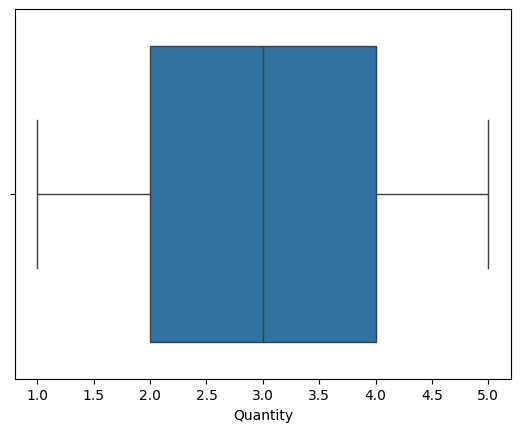

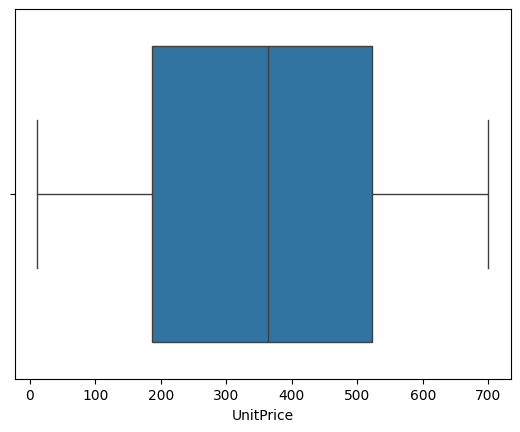

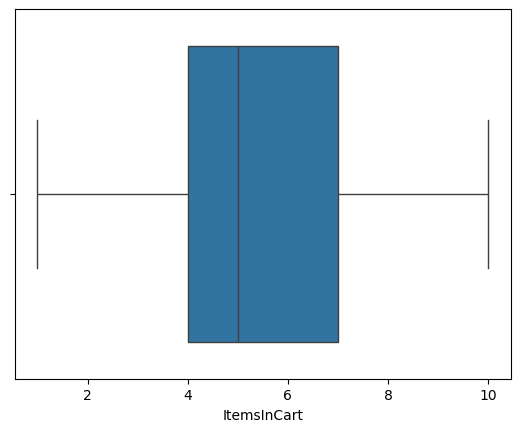

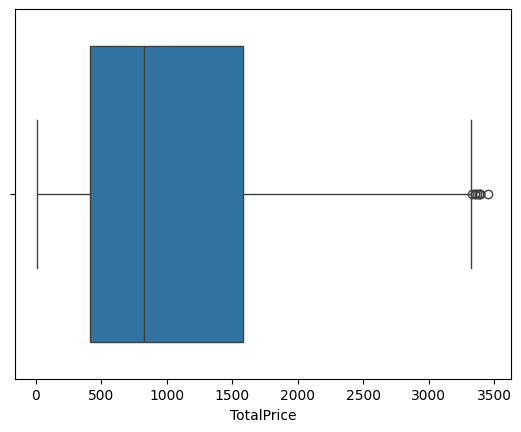

In [99]:
for i in numeric_cols:
    sns.boxplot(x=df[i])
    plt.savefig(f"{i}_boxplot.png", dpi=300, bbox_inches="tight")
    plt.show()

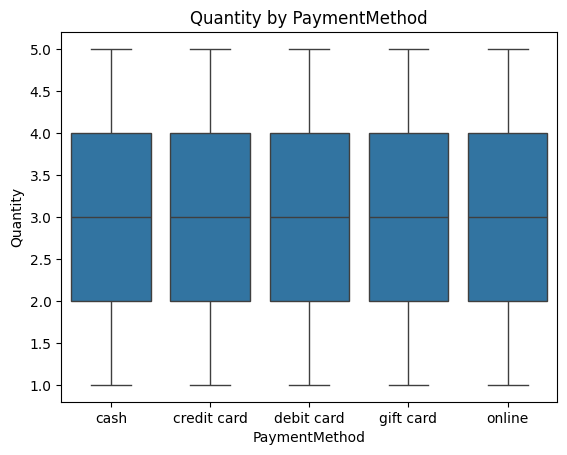

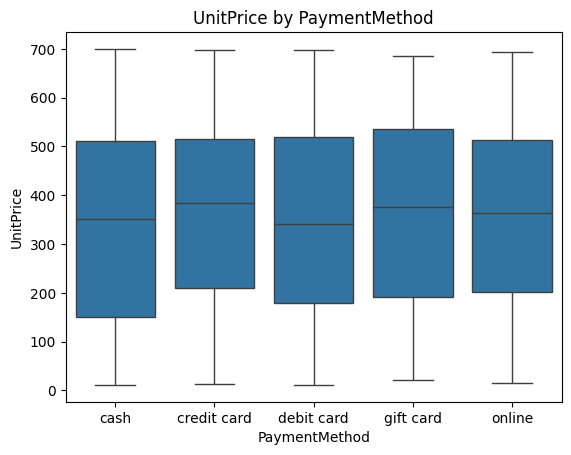

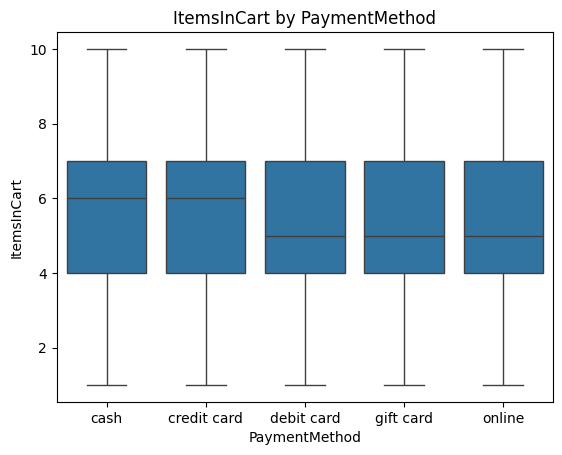

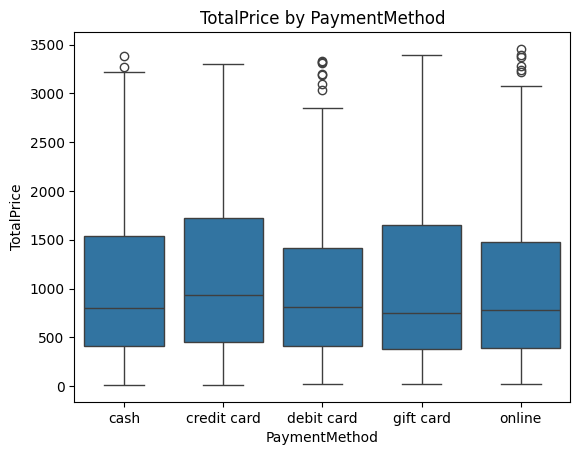

In [100]:
for col in numeric_cols:
    sns.boxplot(
        data=df,
        x="PaymentMethod",
        y=col
    )

    plt.title(f"{col} by PaymentMethod")
    plt.savefig(f"{col}_boxplot_PaymentMethod.png", dpi=300, bbox_inches="tight")
    plt.show()

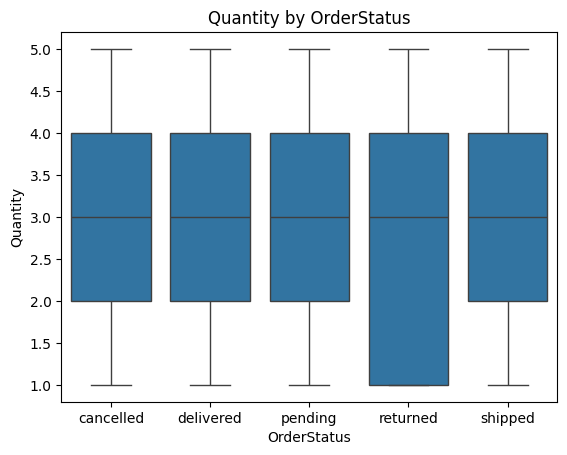

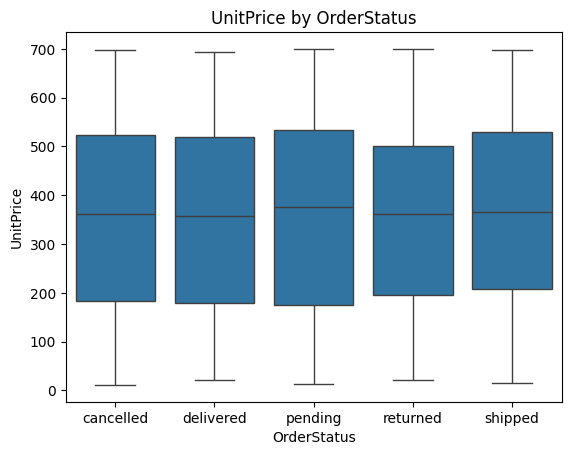

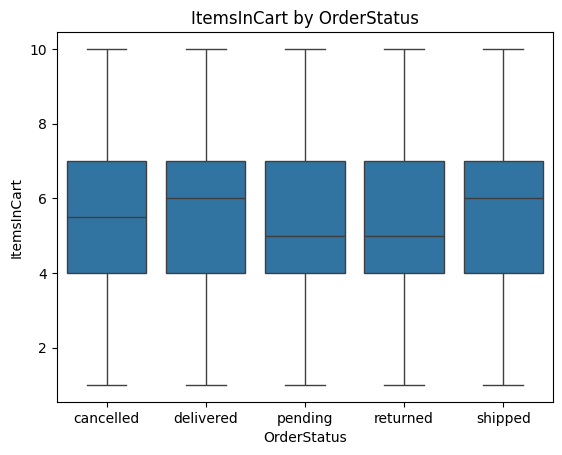

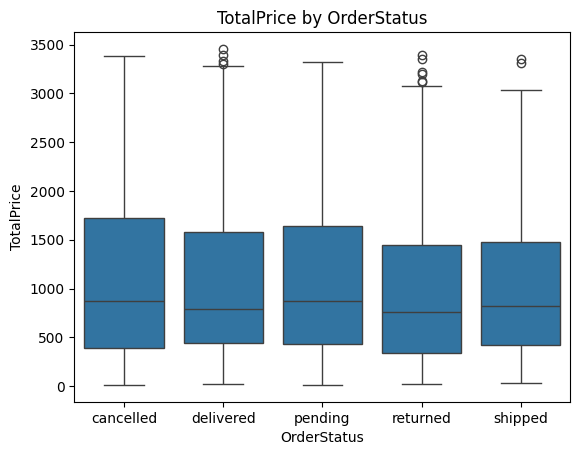

In [101]:
for col in numeric_cols:
    sns.boxplot(
        data=df,
        x="OrderStatus",
        y=col
    )

    plt.title(f"{col} by OrderStatus")
    plt.savefig(f"{col}_boxplot_OrderStatus.png", dpi=300, bbox_inches="tight")
    plt.show()

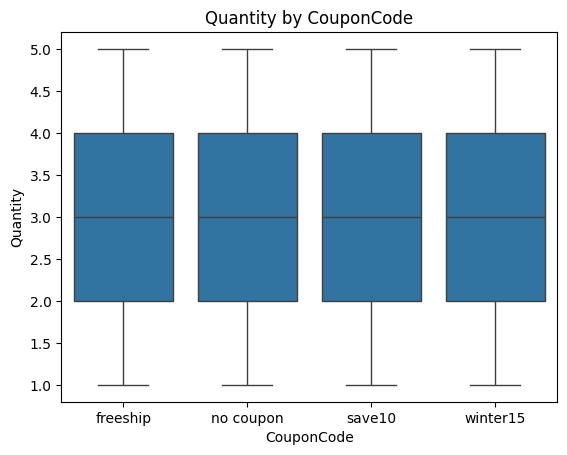

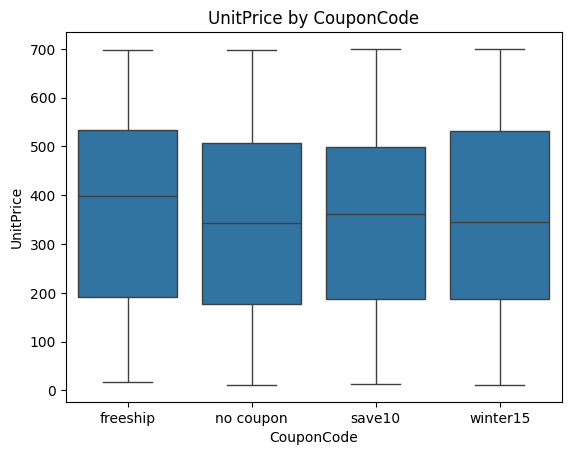

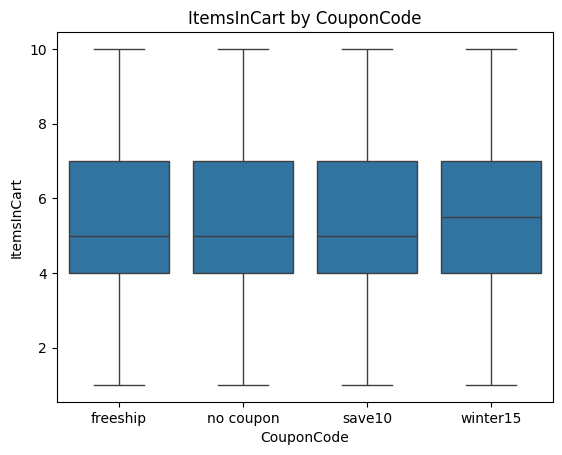

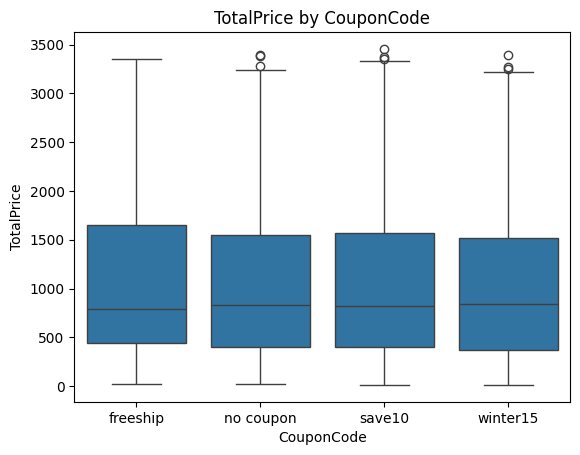

In [102]:
for col in numeric_cols:
    sns.boxplot(
        data=df,
        x="CouponCode",
        y=col
    )

    plt.title(f"{col} by CouponCode")
    plt.savefig(f"{col}_boxplot_CouponCode.png", dpi=300, bbox_inches="tight")
    plt.show()

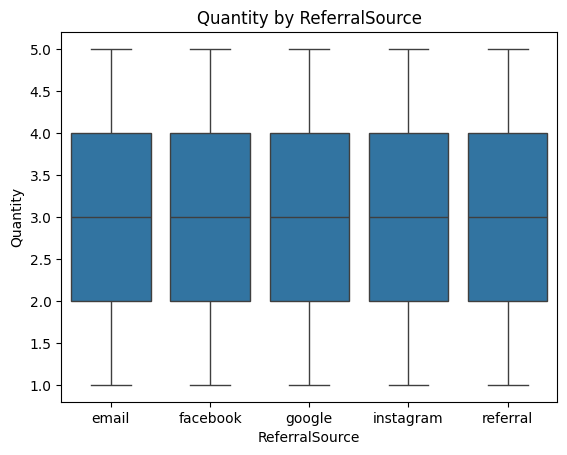

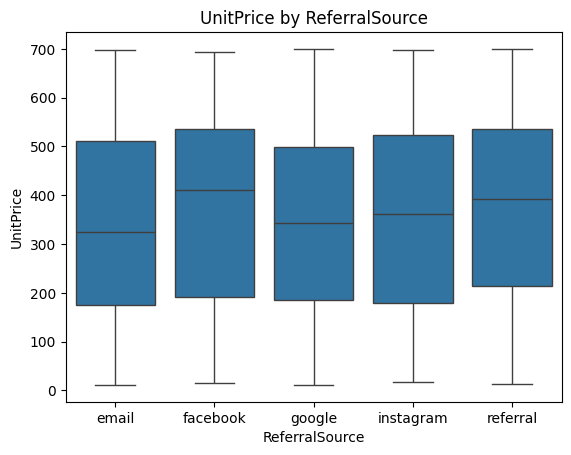

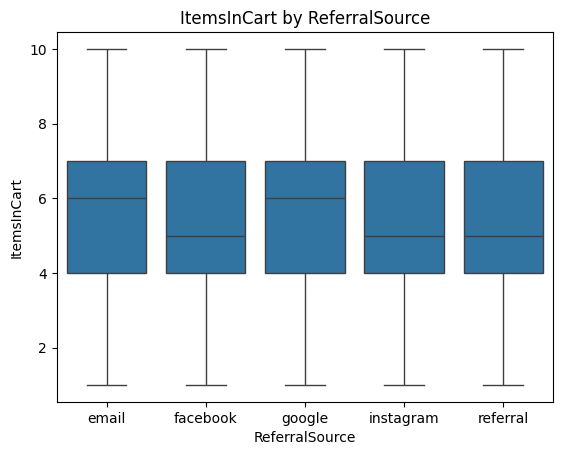

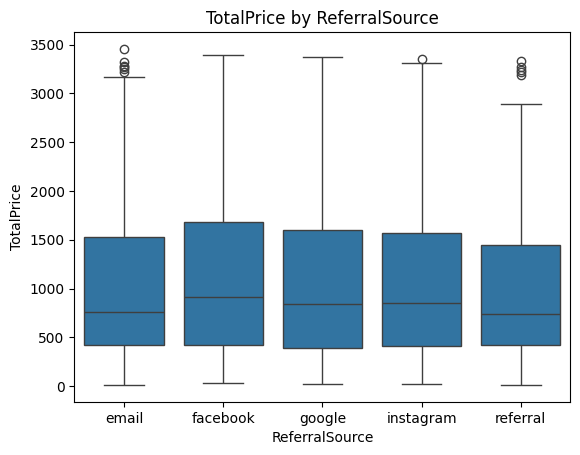

In [105]:
for col in numeric_cols:
    sns.boxplot(
        data=df,
        x="ReferralSource",
        y=col
    )

    plt.title(f"{col} by ReferralSource")
    plt.savefig(f"{col}_boxplot_ReferralSource.png", dpi=300, bbox_inches="tight")

    plt.show()

In [ ]:
for col in ["UnitPrice","TotalPrice"]:
    plt.hist(df[col], bins=7)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

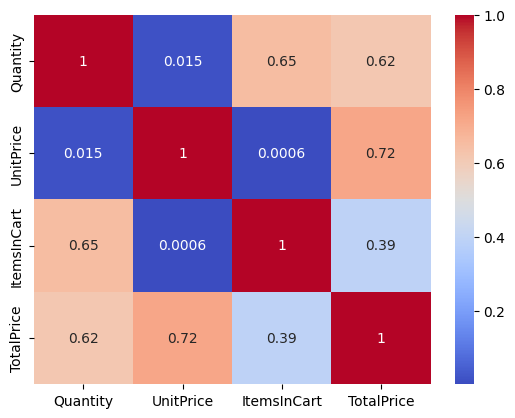

In [104]:
corr_cols = ["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]

corr = df[corr_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.show()